# 020 — Training

Train UNet, ResUNet, Attention UNet, and EfficientNet UNet on the RGB → IR translation task.
Checkpoints are saved to `models/{arch}/best_model.keras`.
Logs are written to `logs/{arch}/` for TensorBoard.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    grouped_train_val_test_split,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.trainer import compile_model, get_callbacks, get_model
from scripts.visualization import plot_training_curves

# Seed Python / NumPy / TensorFlow from settings.SEED for reproducible runs.
set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Build datasets

In [ ]:
# Artworks split logic: every artwork ID (including the paint-on-support
# mockup groups) is a group kept entirely within a single fold, to prevent
# leakage between sections of the same painting. This can hold an entire
# mockup group out of training even though those groups exist to aid it.
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = grouped_train_val_test_split(
    pairs,
    train_ratio= settings.TRAIN_RATIO,
    val_ratio= settings.VAL_RATIO,
    seed=settings.SEED,
)

# crop_size only affects the augmented training split; val stays full-image.
train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

In [3]:
# Artwork and mockups split logic (alternative to the block above): real
# artworks are still grouped and leakage-free, but the mockup groups in
# settings.MOCKUP_ARTWORK_IDS are split at the individual pair level, with
# only a small fraction (default 5%) held out for test — the rest is
# available for train/val. Not wired into training below — rename
# train_pairs_mockups/val_pairs_mockups to train_pairs/val_pairs above (and
# rerun build_dataset) to switch training over to this split.
pairs_mockups = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs_mockups,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


2026-08-11 15:59:20.097742: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-11 15:59:20.097762: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-11 15:59:20.097767: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-11 15:59:20.097778: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-11 15:59:20.097787: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Loss functions

The loss is never passed by hand: it is resolved from the architecture through the
`ARCH_LOSSES` registry in `scripts/config.py` (`get_loss_name` → `build_loss`), so
training and checkpoint reloading can never disagree.

| Architecture | Loss |
|---|---|
| UNet, ResUNet, Attention UNet | `combined_loss` — MAE + (1 − SSIM) |
| EfficientNet UNet | `combined_loss_advanced` — MAE + Laplacian pyramid + FFT |
| *(unassigned)* | `combined_loss_normalized` — MAE + per-window z-score |

The **Laplacian pyramid** loss decomposes prediction error into spatial frequency bands
and weights finer detail more heavily (geometric sequence: level 0 weight = `2^(N-1)`, halved each level).
The **FFT loss** penalises magnitude-spectrum errors uniformly across all frequencies,
preventing the model from sacrificing high-frequency accuracy to reduce low-frequency error.
Both terms target the frequency band where underdrawing strokes live.

`combined_loss_normalized` implements the local-normalization idea from `note.md` §2: it
measures error in units of **local contrast** rather than absolute gray level, which is the
metric the delta is actually read in (`040_inference.ipynb` passes it through CLAHE). Two
things to know before enabling it on an architecture:

- Its z-score term is invariant to local affine gray-level changes, so the MAE anchor is
  mandatory — without it the absolute gray level is unconstrained and the raw delta loses
  its meaning.
- The two terms are not on a comparable scale: `mean|Δz|` measures ~9× the MAE of the same
  prediction on held-out paintings, so `NORM_LOSS_BETA` (0.03) is deliberately far below
  `NORM_LOSS_ALPHA` (1.0). `ZSCORE_SIGMA_FLOOR` (0.01) is the 10th percentile of the local
  standard deviation measured over the IR set, and bounds the gradient in flat regions.

To train an architecture with it, change its entry in `ARCH_LOSSES` to
`LossName.NORMALIZED`; the weights come from `settings` and are `.env`-overridable.

The cell below visualises the pyramid decomposition and FFT spectra of one training sample.

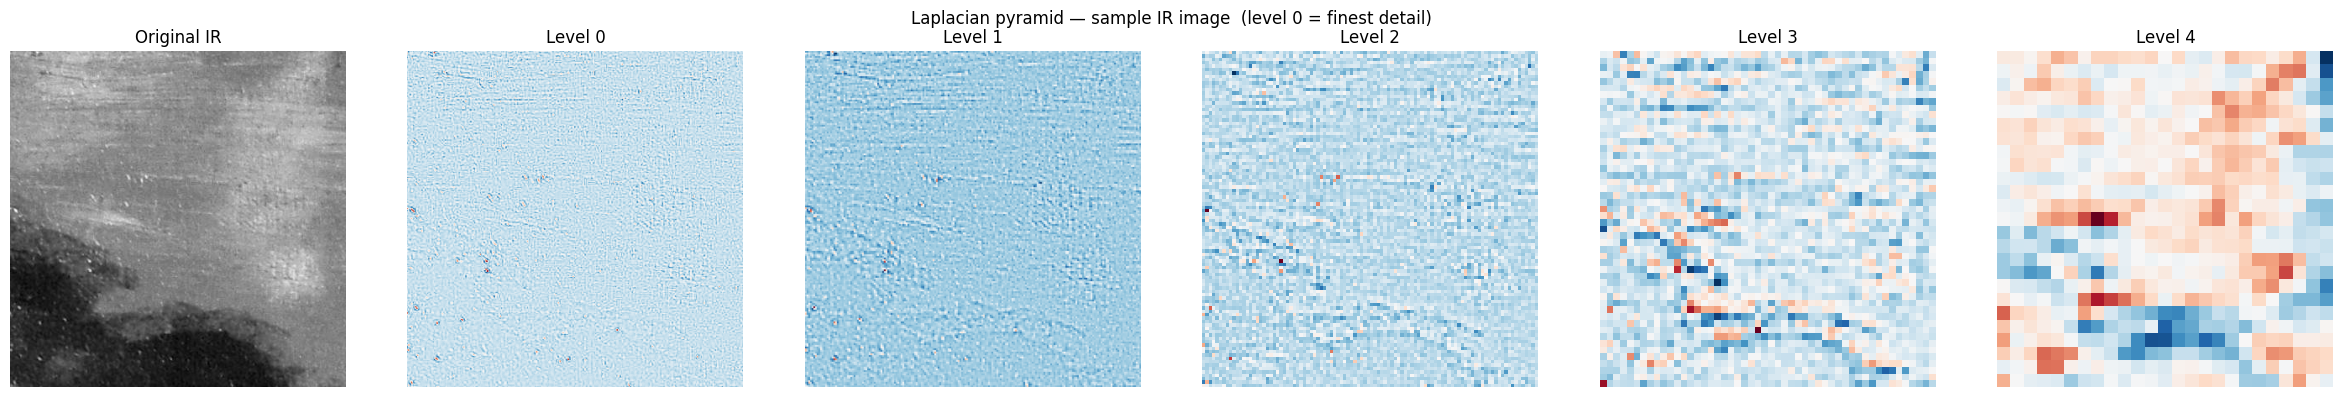

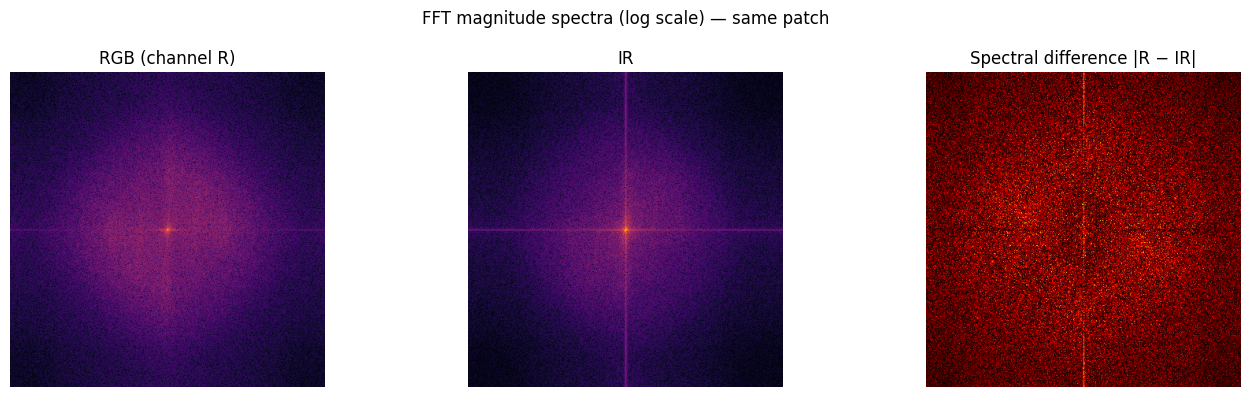

In [4]:
import numpy as np
import tensorflow as tf
from PIL import Image

# --- Laplacian pyramid on a sample IR image ---
ir_np = np.array(Image.open(train_pairs[0][1]).convert("L")).astype(np.float32) / 255.0
ir_t = tf.constant(ir_np[np.newaxis, ..., np.newaxis])  # (1, H, W, 1)


def _lap_level(x: tf.Tensor) -> tuple:
    low = tf.nn.avg_pool2d(x, ksize=2, strides=2, padding="VALID")
    up = tf.image.resize(low, tf.shape(x)[1:3], method="bilinear")
    detail = (x - up)[0, ..., 0].numpy()
    return detail, low


LEVELS = 5
details, x = [], ir_t
for _ in range(LEVELS):
    d, x = _lap_level(x)
    details.append(d)

fig, axes = plt.subplots(1, LEVELS + 1, figsize=(4 * (LEVELS + 1), 4))
fig.suptitle("Laplacian pyramid — sample IR image  (level 0 = finest detail)")
axes[0].imshow(ir_np, cmap="gray")
axes[0].set_title("Original IR")
axes[0].axis("off")
for i, d in enumerate(details):
    d_disp = (d - d.min()) / (d.max() - d.min() + 1e-8)
    axes[i + 1].imshow(d_disp, cmap="RdBu_r")
    axes[i + 1].set_title(f"Level {i}")
    axes[i + 1].axis("off")
plt.tight_layout()
plt.show()

# --- FFT magnitude spectra ---
rgb_np = (
    np.array(Image.open(train_pairs[0][0]).convert("RGB")).astype(np.float32) / 255.0
)
log_rgb = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(rgb_np[..., 0]))))
log_ir = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(ir_np))))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("FFT magnitude spectra (log scale) — same patch")
axes[0].imshow(log_rgb, cmap="inferno")
axes[0].set_title("RGB (channel R)")
axes[0].axis("off")
axes[1].imshow(log_ir, cmap="inferno")
axes[1].set_title("IR")
axes[1].axis("off")
axes[2].imshow(np.abs(log_rgb - log_ir), cmap="hot")
axes[2].set_title("Spectral difference |R − IR|")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## 3. Train all architectures

UNet, ResUNet, and Attention UNet use `combined_loss` (MAE + SSIM).
EfficientNet UNet uses `combined_loss_advanced` (MAE + Laplacian pyramid + FFT),
which better preserves the high-frequency detail that a pretrained encoder can reproduce.

Set `EPOCHS = 2` for a quick smoke test.

In [ ]:
ARCHS = ["efficientnet_unet"]
EPOCHS = settings.EPOCHS  # -- change to settings.EPOCHS for full training

histories: dict = {}

for arch in ARCHS:
    print(f"\n{'=' * 60}")
    print(f"  Architecture: {arch}")
    print(f"{'=' * 60}")

    model = get_model(arch)
    model = compile_model(
        model,
        arch,
        lr=settings.LEARNING_RATE,
        loss_alpha=settings.LOSS_ALPHA,
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(
        arch,
        log_dir=settings.LOGS_DIR,
        model_dir=settings.MODELS_DIR,
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    histories[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")

In [5]:
ARCHS = ["unet", "resunet", "attention_unet", "efficientnet_unet"]
EPOCHS = settings.EPOCHS  # -- change to settings.EPOCHS for full training

histories: dict = {}

for arch in ARCHS:
    print(f"\n{'=' * 60}")
    print(f"  Architecture: {arch}")
    print(f"{'=' * 60}")

    model = get_model(arch)
    model = compile_model(
        model,
        arch,
        lr=settings.LEARNING_RATE,
        loss_alpha=settings.LOSS_ALPHA,
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(
        arch,
        log_dir=settings.LOGS_DIR,
        model_dir=settings.MODELS_DIR,
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    histories[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")


  Architecture: unet


Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, None,      │         256 │ conv2d[0][0]       │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, None,      │      36,864 │ re_lu[0][0]        │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, None,      │         256 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, None,      │           0 │ re_lu_1[0][0]      │
│ (MaxPooling2D)        │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, None,      │      73,728 │ max_pooling2d[0][… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, None,      │         512 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, None,      │     147,456 │ re_lu_2[0][0]      │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_3 │ (None, None,      │         512 │ conv2d_3[0][0]     │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_3 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_1       │ (None, None,      │           0 │ re_lu_3[0][0]      │
│ (MaxPooling2D)        │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, None,      │     294,912 │ max_pooling2d_1[0… │
│                       │ None,

 Total params: 31,049,409 (118.44 MB)

 Trainable params: 31,037,633 (118.40 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ multiply_4 (Multiply) │ (None, None,      │           0 │ input_layer_4[0][… │
│                       │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ efficientnet_b0_enco… │ [(None, None,     │   4,049,571 │ multiply_4[0][0]   │
│ (Functional)          │ None, 16), (None, │             │                    │
│                       │ None, None, 24),  │             │                    │
│                       │ (None, None,      │             │                    │
│                       │ None, 40), (None, │             │                    │
│                       │ None, None, 112), │             │                    │
│                       │ (None, None,      │             │                    │
│                       │ None, 1280)]      │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_78 (Conv2D)    │ (None, None,      │   2,949,120 │ efficientnet_b0_e… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │       1,024 │ conv2d_78[0][0]    │
│ (BatchNormalization)  │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_58 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_79 (Conv2D)    │ (None, None,      │     589,824 │ re_lu_58[0][0]     │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │       1,024 │ conv2d_79[0][0]    │
│ (BatchNormalization)  │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_59 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_transpose_12   │ (None, None,      │     131,200 │ re_lu_59[0][0]     │
│ (Conv2DTranspose)     │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ __resize_to_match     │ (None, None,      │           0 │ conv2d_transpose_… │
│ (_ResizeToMatch)      │ None, 128)        │             │ efficientnet_b0_e… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate_12        │ (None, None,      │           0 │ __resize_to_match… │
│ (Concatenate)         │ None, 240)        │             │ efficientnet_b0_e… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_80 (Conv2D)    │ (None, None,      │     276,480 │ concatenate_12[0]… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         512 │ conv2d_80[0][0]    │
│ (BatchNormalization)  │ None,

 Total params: 8,325,556 (31.76 MB)

 Trainable params: 4,273,937 (16.30 MB)

 Non-trainable params: 4,051,619 (15.46 MB)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.2091 - mae: 0.1812 - psnr: 14.0094 - ssim: 0.0846
Epoch 1: val_loss improved from None to 0.16500, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/efficientnet_unet/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/efficientnet_unet/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - loss: 0.2091 - mae: 0.1812 - psnr: 14.0094 - ssim: 0.0846 - val_loss: 0.1650 - val_mae: 0.1382 - val_psnr: 16.9514 - val_ssim: 0.3201 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.1646 - mae: 0.1375 - psnr: 16.6474 - ssim: 0.1992
Epoch 2: val_loss improved from 0.16500 to 0.15965, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/efficientnet_unet/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/efficientnet_unet/best_model.k

## 3. Training curves

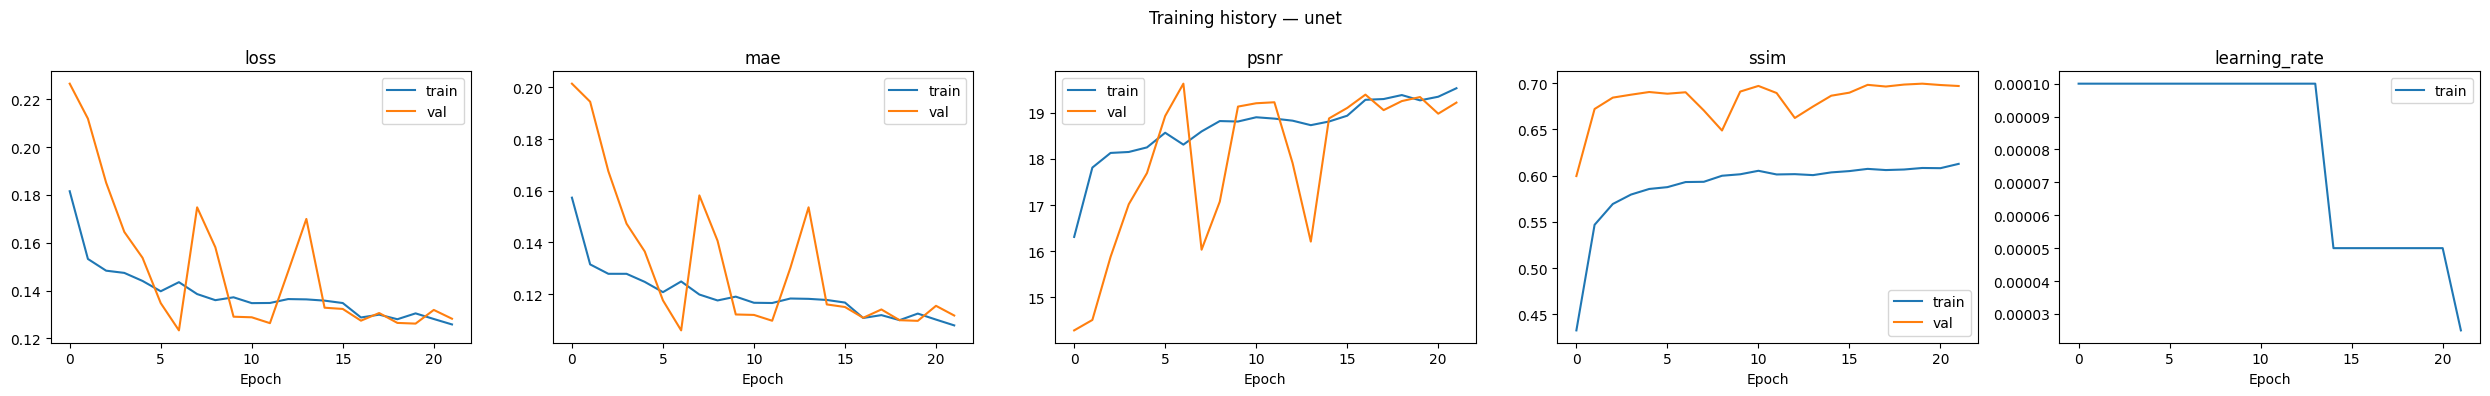

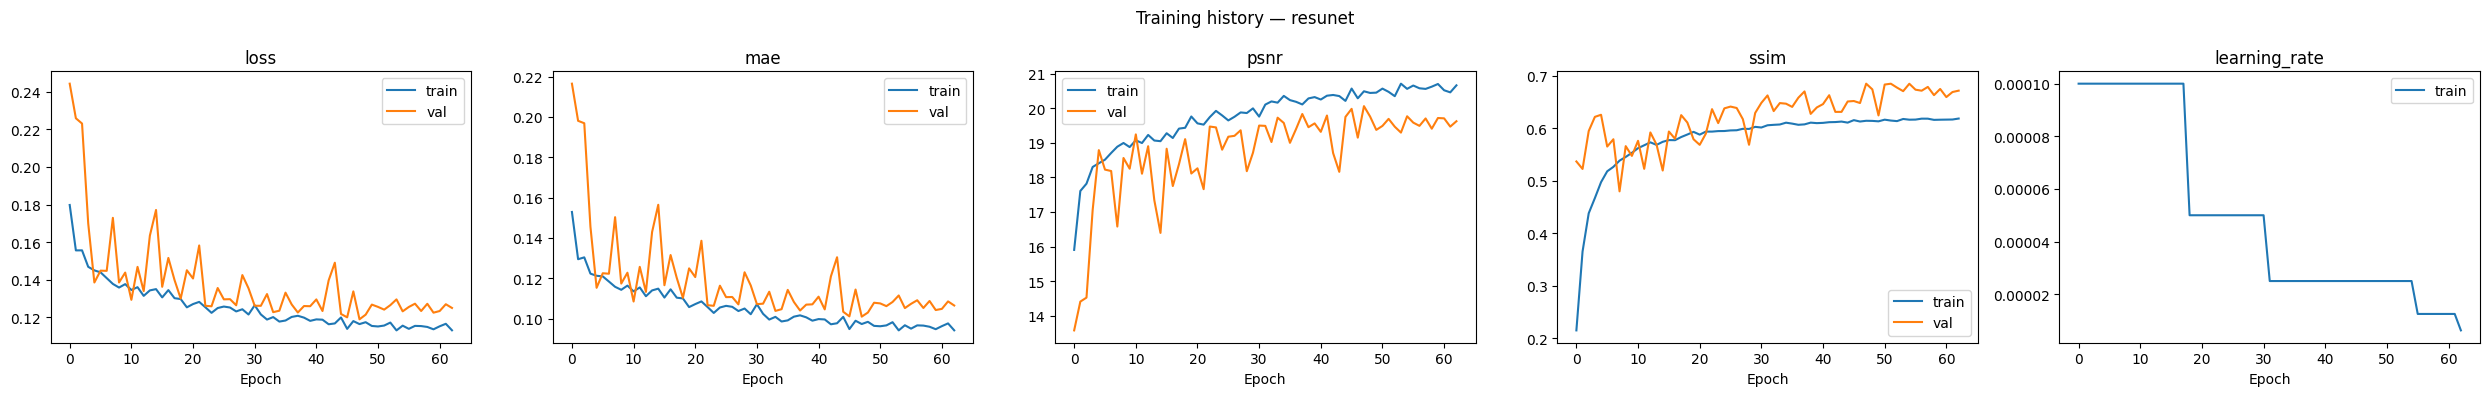

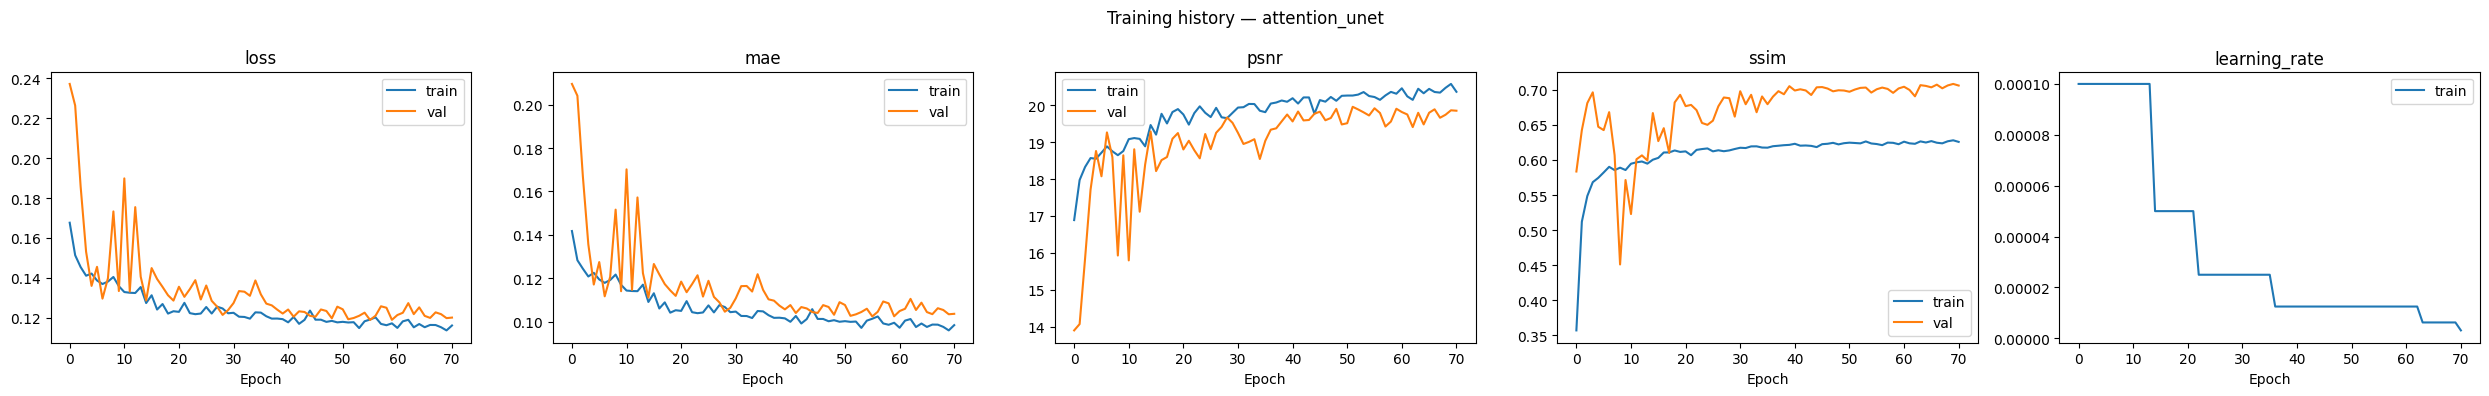

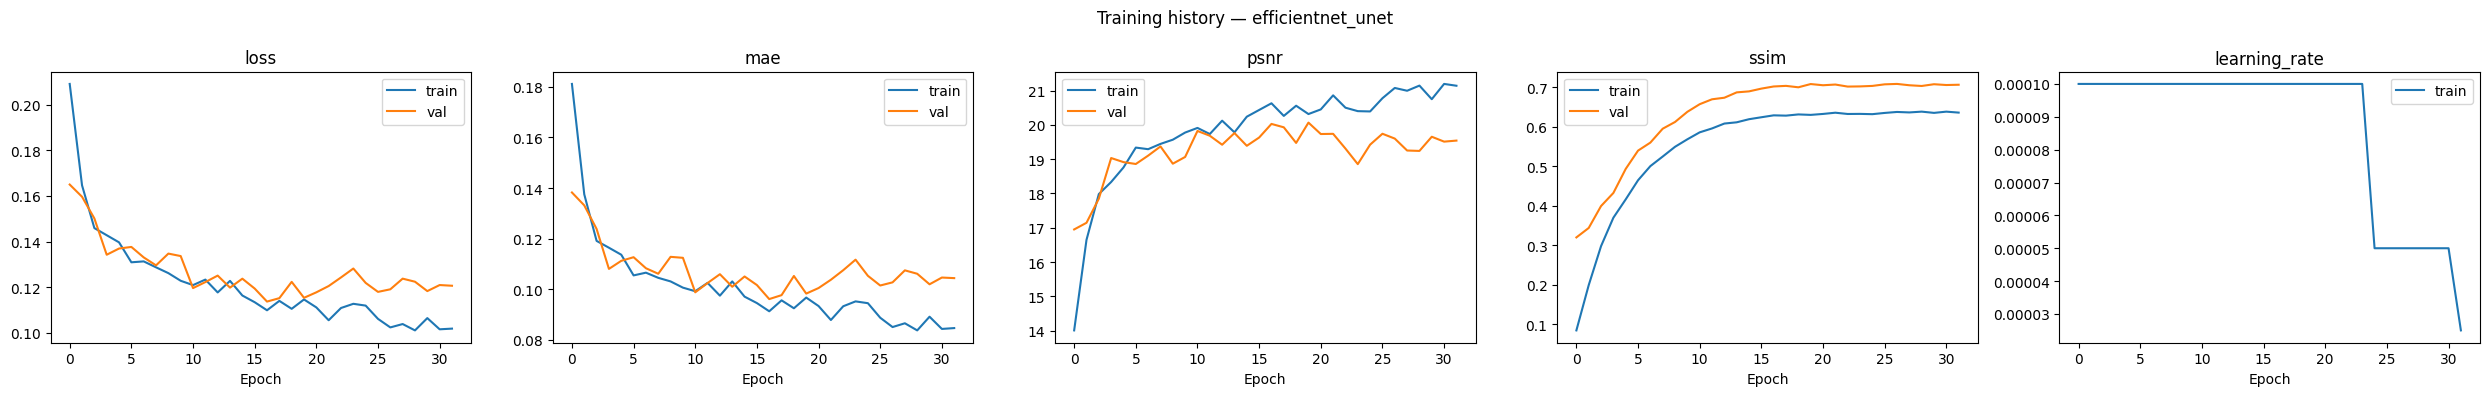

In [7]:
for arch, history in histories.items():
    fig = plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

## 4. Summary

Checkpoints saved to `models/{arch}/best_model.keras`.  
Run `tensorboard --logdir logs/` to inspect curves interactively.

> **Note:** `efficientnet_unet` downloads EfficientNetB0 ImageNet weights on first use.
> Subsequent runs use the local Keras cache.

In [ ]:
for arch in ARCHS:
    ckpt = settings.MODELS_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25}: {status}  ({ckpt})")